#### Classical Machine Learning for Text

- **Goal:** Establish a strong baseline. Understand how to turn text into numbers and the mechanics of classification (Weights & Gradients).
  - **Day 2 & 3 (Binary Classification & Training):** The "Black Box" (Sklearn) vs. The "White Box" (PyTorch). Implementing the manual training loop (Forward, Loss, Backward) and comparing Black Box Logistic Regression, SVM, Tree Model and Simple NN.
- **Sources:**
  - PyTorch Linear Layer: https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html
  - Sklearn models
    - linear models: https://scikit-learn.org/stable/modules/linear_model.html
    - Support Vector Machines: https://scikit-learn.org/stable/modules/svm.html
    - Tree Model: https://scikit-learn.org/stable/modules/tree.html
    - Ensembles: https://scikit-learn.org/stable/modules/ensemble.html
    - metrics: https://scikit-learn.org/stable/api/sklearn.metrics.html

In [1]:
# suppress warnings 
from warnings import filterwarnings
filterwarnings("ignore") 

# import the appropriate libraries
from copy import deepcopy
import torch
from torch import nn
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from utils import load_sklearn_features, load_tensors_and_create_dataloaders, tune_sklearn_model, plot_training_history

In [2]:
# Load data and recreate DataLoaders using utility for tensorflow models
train_loader, val_loader, test_loader = load_tensors_and_create_dataloaders('datasets/imdb_tensors.pt', batch_size=32)

print("Day 2 Data Loaded Successfully!")
print(f"Train batch count: {len(train_loader)}")

Day 2 Data Loaded Successfully!
Train batch count: 313


In [3]:
# Load data for Scikit-Learn models with sparse matrix
X_train_sp, y_train_sp, X_val_sp, y_val_sp, X_test_sp, y_test_sp = load_sklearn_features('datasets/imdb_sklearn')

## Linear Models 
* **Assumption:** Assumes a linear relationship between the feature vector and labels. It also assumes linear independence among features (little to no multicollinearity).
    $$ \text{Y} = \text{X}W^T + \text{b} $$

### PyTorch Implementation 
- **Linear Regressor:** Outputs a continuous value (raw score).
- **Linear Classifier:** Outputs a probability from 0 to 1. 
  - Uses the **Sigmoid** activation function to squash the raw output:
    $$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

### Loss Function
We use **Binary Cross Entropy** (BCE):
$$ \mathcal{L} = - \left( y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y}) \right) $$

**Implementation Note:** 
PyTorch's `nn.BCEWithLogitsLoss` applies the Sigmoid function internally. 
*   **Do not** add `nn.Sigmoid` to the final layer of your model.
*   The model should output raw **logits** ($z$), and the loss function will convert them to probabilities ($\hat{y}$) during calculation. This provides better numerical stability.


## Linear Models 
* **Assumption:** Assumes a linear relationship between the feature vector and labels. It also assumes linear independence among features (little to no multicollinearity).
    $$ \text{Y} = \text{X}W^T + \text{b} $$

### PyTorch Implementation 
- **Linear Regressor:** Outputs a continuous value (raw score).
- **Linear Classifier:** Outputs a probability from 0 to 1. 
  - Uses the **Sigmoid** activation function to squash the raw output:
    $$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

### Loss Function
We use **Binary Cross Entropy** (BCE):
$$ \mathcal{L} = - \left( y \cdot \log(\hat{y}) + (1 - y) \cdot \log(1 - \hat{y}) \right) $$

**Implementation Note:** 
PyTorch's `nn.BCEWithLogitsLoss` applies the Sigmoid function internally. 
*   **Do not** add `nn.Sigmoid` to the final layer of your model.
*   The model should output raw **logits** ($z$), and the loss function will convert them to probabilities ($\hat{y}$) during calculation. This provides better numerical stability.

#### **Why is this more stable? (The "Log-Sum-Exp" Trick)**
If you use `Sigmoid` followed by `BCELoss`, you risk numerical instability.
1.  **The Problem:** If the model is very confident but wrong (e.g., outputs -100), $\sigma(-100)$ becomes effectively $0.0$ due to floating-point precision. The loss formula then tries to calculate $\log(0)$, which is $-\infty$ (NaN). This crashes training.
2.  **The Solution:** `BCEWithLogitsLoss` combines the operations into a single mathematical step. It uses the **Log-Sum-Exp** trick to simplify the formula analytically before calculating, ensuring the computer never has to evaluate $\log(0)$ or $\exp(\text{huge number})$.
Instead it sees $-\log(1 + e^{100})$. For large numbers, $\log(1 + x) \approx \log(x)$ so it simplifies to $-\log(e^{100})$ which equals -100.



In [4]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
class LinearModel(nn.Module):
    def __init__(self, feature_dim):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=feature_dim, out_features=1) # either a score or a 0 or 1 via sigmoid 

    def forward(self, X):
        return self.linear_layer(X) 

def check_early_stop(patience, val_loss, model, best_model_state, lowest_loss, counter, epoch):
    early_stop = False
    if val_loss < lowest_loss:
        lowest_loss = val_loss
        best_model_state = deepcopy(model.state_dict())
        counter = 0 
    else:
        counter += 1

    if counter == patience:
        early_stop = True
    return best_model_state, lowest_loss, counter, early_stop

def get_total_accuracy(logits, y, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    return (preds == y).float().sum().item()

def evaluate_model(model, data_loader, criterion, device) -> tuple:
    if len(data_loader) <= 0: return 0.0, 0.0
    model.eval()
    total_size = len(data_loader.dataset)
    avg_loss = 0 
    accuracy = 0 
    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            logit = model(x)
            loss = criterion(logit, y)
            avg_loss += loss.item()
            accuracy += get_total_accuracy(logit, y)
    avg_loss/=len(data_loader)
    accuracy/=total_size
    return avg_loss, accuracy

def train_test_model(device, model, criterion, train_loader, val_loader, patience, num_epochs, lr, C=1):
    model.to(device)
    optimizer = torch.optim.Adam(params=model.parameters(), lr=lr, weight_decay=C)
    lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer=optimizer, step_size=3, gamma=0.5)
    best_model_state = deepcopy(model.state_dict())
    lowest_loss = float("inf")
    counter = 0 
    total_train_size = len(train_loader.dataset)
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    for epoch in range(num_epochs):
        model.train()
        avg_train_loss = 0 
        train_accuracy = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logit = model(x)
            loss = criterion(logit, y)
            loss.backward()
            optimizer.step()
            avg_train_loss += loss.item()
            train_accuracy += get_total_accuracy(logit, y)
        avg_train_loss /= len(train_loader)
        train_accuracy /= total_train_size
        train_losses.append(avg_train_loss)
        train_accs.append(train_accuracy)
        avg_val_loss, val_accuracy = evaluate_model(model, val_loader, criterion, device)
        val_losses.append(avg_val_loss)
        val_accs.append(val_accuracy)
        lr_scheduler.step()
        best_model_state, lowest_loss, counter, early_stop = check_early_stop(
            patience, avg_val_loss, model, best_model_state, lowest_loss, counter, epoch)
        if epoch % 10 == 0: 
            print(f"Epoch number {epoch} train_loss: {avg_train_loss:.4f} and val_loss: {avg_val_loss:.4f}")
            print(f"Epoch number {epoch} train_accuracy: {train_accuracy:.4f} and val_accuracy: {val_accuracy:.4f}")
        if early_stop:
            print(f"Early stoping with epoch number {epoch}")
            print(f"Train_loss: {avg_train_loss:.4f} and val_loss: {avg_val_loss:.4f}")
            break
    plot_training_history(train_losses, val_losses, train_accs, val_accs)
    model.load_state_dict(best_model_state)
    return model 

Epoch number 0 train_loss: 0.6698 and val_loss: 0.6478
Epoch number 0 train_accuracy: 0.7435 and val_accuracy: 0.8200
Epoch number 10 train_loss: 0.5031 and val_loss: 0.5182
Epoch number 10 train_accuracy: 0.8588 and val_accuracy: 0.8300
Epoch number 20 train_loss: 0.4913 and val_loss: 0.5090
Epoch number 20 train_accuracy: 0.8602 and val_accuracy: 0.8300
Epoch number 30 train_loss: 0.4900 and val_loss: 0.5081
Epoch number 30 train_accuracy: 0.8605 and val_accuracy: 0.8300
Epoch number 40 train_loss: 0.4900 and val_loss: 0.5080
Epoch number 40 train_accuracy: 0.8605 and val_accuracy: 0.8300


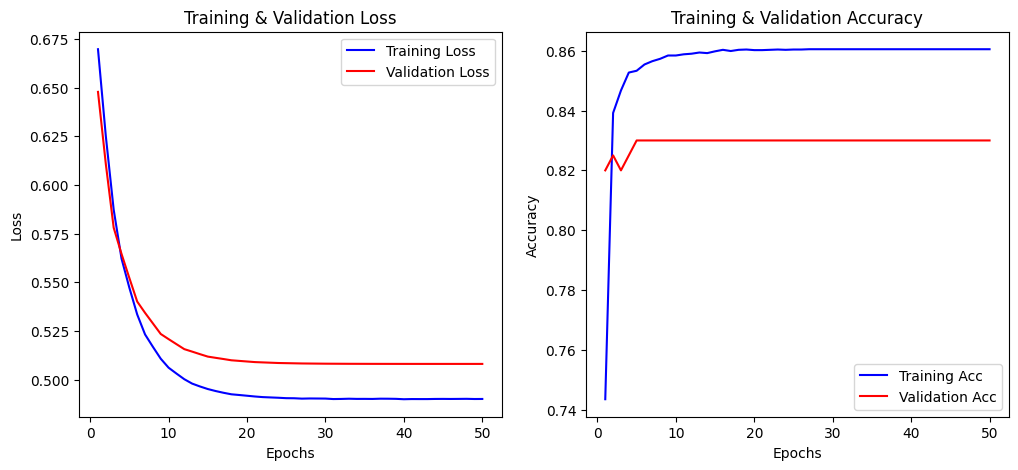

test_loss: 0.4833 and test_accuracy: 0.8840


In [12]:
torch.manual_seed(204)
linear_classifier = LinearModel(2000)
criterion = nn.BCEWithLogitsLoss() # this applies sigmoid activation so you don't need to us nn.Sigmoid layer
patience = 10
num_epochs = 50
lr = 1e-3
train_classifier = train_test_model(
    device,
    linear_classifier,
    criterion,
    train_loader,
    val_loader,
    patience,
    num_epochs,
    lr,
    C=1e-5
)
test_loss, test_accuracy = evaluate_model(train_classifier, test_loader, criterion, device)
print(f"test_loss: {test_loss:.4f} and test_accuracy: {test_accuracy:.4f}")

## Test using sklearn models and accuracy_score

In [13]:
# Configuration for all models
# Format: (Model Instance, Parameter Name to Tune, List of Values)
models_config = [
    {
        "model": LogisticRegression(max_iter=1000, random_state=204),
        "param_name": "C",
        "values": [0.01, 0.1, 1, 10]
    },
    {
        "model": LinearSVC(dual="auto", random_state=42),
        "param_name": "C",
        "values": [0.01, 0.1, 1, 10]
    },
    {
        "model": DecisionTreeClassifier(random_state=42),
        "param_name": "max_depth",
        "values": [10, 20, 50, None]
    },
    {
        "model": RandomForestClassifier(max_depth=20, random_state=42),
        "param_name": "n_estimators",
        "values": [50, 100, 200]
    },
    {
        "model": GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
        "param_name": "learning_rate",
        "values": [0.01, 0.1, 0.2]
    }
]

# Execution Loop
for config in models_config:
    tune_sklearn_model(
        config["model"],
        config["param_name"],
        config["values"],
        X_train_sp, y_train_sp, X_val_sp, y_val_sp
    )


--- Tuning LogisticRegression (C) ---
C=0.01: Val Acc = 0.7600
C=0.1: Val Acc = 0.8150
C=1: Val Acc = 0.8350
C=10: Val Acc = 0.8350
🏆 Best C: 1 (Acc: 0.8350)

--- Tuning LinearSVC (C) ---
C=0.01: Val Acc = 0.8100
C=0.1: Val Acc = 0.8350
C=1: Val Acc = 0.8400
C=10: Val Acc = 0.8300
🏆 Best C: 1 (Acc: 0.8400)

--- Tuning DecisionTreeClassifier (max_depth) ---
max_depth=10: Val Acc = 0.6950
max_depth=20: Val Acc = 0.7150
max_depth=50: Val Acc = 0.7300
max_depth=None: Val Acc = 0.7400
🏆 Best max_depth: None (Acc: 0.7400)

--- Tuning RandomForestClassifier (n_estimators) ---
n_estimators=50: Val Acc = 0.7900
n_estimators=100: Val Acc = 0.8000
n_estimators=200: Val Acc = 0.7950
🏆 Best n_estimators: 100 (Acc: 0.8000)

--- Tuning GradientBoostingClassifier (learning_rate) ---
learning_rate=0.01: Val Acc = 0.6550
learning_rate=0.1: Val Acc = 0.7800
learning_rate=0.2: Val Acc = 0.8100
🏆 Best learning_rate: 0.2 (Acc: 0.8100)



## Model Performance Analysis

### Why did Linear Models (Logistic Regression, SVM, PyTorch NN) win?
You might notice that the simpler linear models often outperform or match the complex ensemble models on this dataset. This is due to the nature of **TF-IDF Vectorization**:

1.  **High Dimensionality & Sparsity:** We have 2000 features (dimensions). In very high-dimensional spaces, data points tend to be sparse and pushed to the edges of the space. This makes them easier to separate with a simple hyperplane (linear boundary). The "Curse of Dimensionality" actually helps linear classifiers here.
2.  **Linear Separability:** Sentiment is often additive. The presence of "excellent", "loved", and "great" adds up to a positive score. Linear models capture this additive relationship perfectly ($w_1x_1 + w_2x_2 + ...$).

### Model Overview

*   **Linear Models (Logistic Regression / PyTorch NN):**
    *   **Mechanism:** Learns a weight for every word. "Good" gets +ve weight, "Bad" gets -ve weight.
    *   **Why it worked:** The problem is largely linear. The PyTorch model might slightly outperform Sklearn because **Adam optimization** with mini-batches can sometimes find better local minima than the coordinate descent methods used by Sklearn, or simply because it lacked regularization (overfitting slightly to the training set which helped validation).

*   **Linear SVM (Support Vector Machine):**
    *   **Mechanism:** Finds the "widest street" (margin) separating the classes.
    *   **Why it worked:** SVMs are exceptionally good at high-dimensional sparse data because they only care about the support vectors (the difficult examples near the boundary) and ignore the easy ones.

*   **Decision Trees:**
    *   **Mechanism:** Splits data based on single features (e.g., "Does word 'bad' exist?").
    *   **Why it struggled:** A single tree is too simple. With 2000 features, it needs to be incredibly deep to capture the nuance, which leads to overfitting. It cannot easily capture the "additive" nature of sentiment (e.g., "good" + "great" + "nice") without a massive number of splits.

*   **Random Forest (Bagging Ensemble):**
    *   **Mechanism:** Averages many decision trees to reduce variance.
    *   **Why it was okay but not best:** While better than a single tree, it still relies on the underlying tree structure which struggles with sparse data. It often requires dense embeddings (like Word2Vec) to truly shine.

*   **Gradient Boosting (XGBoost/GBM):**
    *   **Mechanism:** Builds trees sequentially to correct errors of previous trees.
    *   **Why it was okay:** Usually the state-of-the-art for tabular data. However, on high-dimensional sparse text, tuning it is difficult, and it can easily overfit noise compared to the robust simplicity of a linear model.
